# Baseline - results Top-1, Top-5 and MRR 

## Python imports

In [1]:
import matplotlib.pyplot as pyplt
import pandas as pd
import Common

## Obtain data

Read Floralens dataset (required for data source information) and FLTS results.

In [2]:
dset_data = pd.read_csv('../floralens/floralens_dataset.tsv', sep='\t')
data = pd.read_csv('../floralens/flts_floralens.tsv', sep='\t')
data = data.merge(dset_data, on=['filename', 'species'])
data

,filename,species,rank1,c1,rank2,c2,rank3,c3,rank4,c4,rank5,c5,url,source_url,set,repos,gbif_id
0,Acacia_dealbata_1945424512_1.jpg,Acacia dealbata,Acacia dealbata,0.796078,Acacia longifolia,0.105882,Hakea salicifolia,0.011765,Acacia melanoxylon,0.011765,Medicago arborea,0.003922,https://storage.googleapis.com/floraondata/ina...,https://www.gbif.org/occurrence/1945424512,TEST,iNaturalist,1.945425e+09
1,Acacia_dealbata_2974327900_1.jpg,Acacia dealbata,Acacia mearnsii,0.227451,Pteridium aquilinum,0.203922,Acacia dealbata,0.141176,Paraserianthes lophantha,0.015686,Dryopteris affinis,0.007843,https://storage.googleapis.com/floraondata/Pla...,https://www.gbif.org/occurrence/2974327900,TEST,Pl@ntNet,2.974328e+09
2,Acacia_dealbata_1946199420_3.jpg,Acacia dealbata,Salix fragilis,0.117647,Quercus suber,0.082353,Schoenoplectus lacustris,0.027451,Cryptomeria japonica,0.027451,Acacia dealbata,0.023529,https://storage.googleapis.com/floraondata/ina...,https://www.gbif.org/occurrence/1946199420,TEST,iNaturalist,1.946199e+09
3,Acacia_dealbata_1945436102_1.jpg,Acacia dealbata,Buddleja davidii,0.247059,Ipomoea indica,0.058824,Ficus carica,0.054902,Solanum villosum,0.054902,Datura stramonium,0.035294,https://storage.googleapis.com/floraondata/ina...,https://www.gbif.org/occurrence/1945436102,TEST,iNaturalist,1.945436e+09
4,Acacia_dealbata_1805367892_1.jpg,Acacia dealbata,Acacia dealbata,0.615686,Bupleurum fruticosum,0.058824,Acacia saligna,0.047059,Pittosporum undulatum,0.019608,Acacia melanoxylon,0.015686,https://storage.googleapis.com/floraondata/ina...,https://www.gbif.org/occurrence/1805367892,TEST,iNaturalist,1.805368e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29355,Zostera_noltii_2242774794_1.jpg,Zostera noltii,Cymodocea nodosa,0.388235,Hordeum secalinum,0.105882,Zannichellia palustris,0.043137,Genista florida,0.027451,Anthoxanthum odoratum,0.015686,https://storage.googleapis.com/floraondata/ina...,https://www.gbif.org/occurrence/2242774794,TEST,iNaturalist,2.242775e+09
29356,Zostera_noltii_1972305757_1.jpg,Zostera noltii,Zostera noltii,0.972549,Ruppia maritima,0.011765,Ruppia cirrhosa,0.007843,Zostera marina,0.003922,Cymodocea nodosa,0.003922,https://storage.googleapis.com/floraondata/Obs...,https://www.gbif.org/occurrence/1972305757,TEST,Observation.org,1.972306e+09
29357,Zostera_noltii_1931477974_1.jpg,Zostera noltii,Zostera noltii,0.952941,Zostera marina,0.035294,Cymodocea nodosa,0.007843,Potamogeton trichoides,0.003922,Cerastium semidecandrum,0.000000,https://storage.googleapis.com/floraondata/ina...,https://www.gbif.org/occurrence/1931477974,TEST,iNaturalist,1.931478e+09
29358,Zostera_noltii_3112502324_2.jpg,Zostera noltii,Pilularia globulifera,0.274510,Ruppia maritima,0.243137,Juncus bulbosus,0.121569,Eleocharis acicularis,0.082353,Potamogeton trichoides,0.031373,https://storage.googleapis.com/floraondata/ina...,https://www.gbif.org/occurrence/3112502324,TEST,iNaturalist,3.112502e+09


In [3]:
results = [ ]
results.append([
    'Overall', 
    Common.top1(data),
    Common.top5(data),
    Common.mrr(data)
])
for repos in ['FloraOn','iNaturalist','Observation.org','Pl@ntNet']:
    repos_data = data[data.repos == repos]
    results.append([
        repos,
        Common.top1(repos_data),
        Common.top5(repos_data),
        Common.mrr(repos_data)
    ])

plot_data = pd.DataFrame(results, columns=['Data Source','Top-1','Top-5','MRR'])
plot_data

,Data Source,Top-1,Top-5,MRR
0,Overall,0.668495,0.861240,0.745110
1,FloraOn,0.696129,0.879355,0.771333
2,iNaturalist,0.697752,0.868867,0.767178
3,Observation.org,0.644624,0.833978,0.718115
4,Pl@ntNet,0.658408,0.874464,0.744167


## Derive plot with results

findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


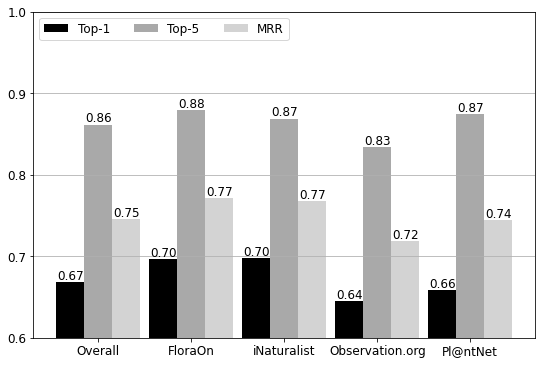

In [4]:
font = {'family' : 'normal',
        'size'   : 12}

pyplt.rc('font', **font)
pyplt.rcParams["figure.figsize"] = (9,6)

plt = plot_data.plot.bar(x='Data Source',y=['Top-1','Top-5', 'MRR'],color=['black','darkgray','lightgray'],width=0.9)
plt.legend(loc='upper left',ncol=3)
plt.set_ylim([0.60,1.0])
plt.set_xlabel('')
plt.set_yticks([0.60,0.70,0.80,0.90,1.0])
plt.grid(axis='y')
plt.set_xticklabels(['Overall','FloraOn','iNaturalist','Observation.org','Pl@ntNet'], rotation=0, ha='center')

for container in plt.containers:
  plt.bar_label(container,fmt='%.2f')
plt.get_figure().savefig('plot_images/floralens_baseline_results.pdf',bbox_inches='tight')